# Revised EDA

## Module Imports

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

## Data Import

In [21]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

df = torch.load(chunksFilePath / 'SampledData-10Percent.pth', map_location="cpu", weights_only=False)

In [22]:
df.columns

Index(['ID', 'longitude', 'latitude', 'elevation', 'slope', 'aspect',
       'soil_moisture_0_5cm', 'soil_moisture_5_15cm', 'soil_moisture_15_30cm',
       'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08',
       'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'level0', 'level1_family', 'level2_genus',
       'imgData', 'level3_species'],
      dtype='object')

# Hierarchy
- Count unique values of levels 0, 1, 2, 3

In [23]:
levels = [col for col in df.columns if 'level' in col]
valueCounts = []

for level in levels:
    vc = df[level].value_counts().reset_index()
    vc.columns = [level, 'count']
    vc['level'] = level
    valueCounts.append(vc)

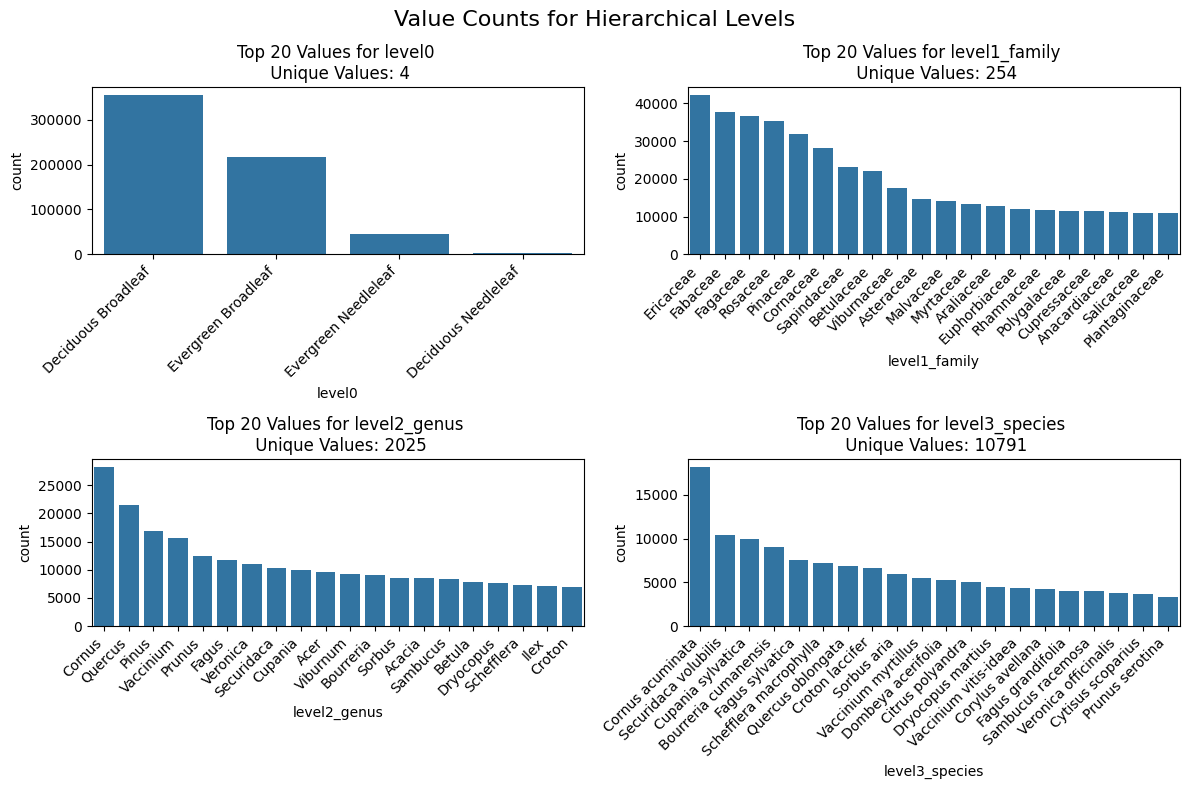

In [26]:
# plot top 20 values for each level

figHi, axHi = plt.subplots(2, 2, figsize=(6 * 2, 4*2))

for i, vc in enumerate(valueCounts):
    a = i // 2
    b = i % 2
    sns.barplot(data=vc.head(20), y='count', x=vc.columns[0], ax=axHi[a, b])
    axHi[a, b].set_title(f'Top 20 Values for {vc.columns[0]} \n Unique Values: {vc.shape[0]}')
    axHi[a, b].tick_params(axis='x', rotation=45)
    for label in axHi[a, b].get_xticklabels():
        label.set_horizontalalignment('right')
        label.set_verticalalignment('top')

figHi.suptitle('Value Counts for Hierarchical Levels', fontsize=16)
figHi.tight_layout()

- Very significant class imbalances
- Signifcantly more unique groups in higher classification levels

In [28]:
# minimum value frequency per level
for vc in valueCounts:
    min_count = vc['count'].min()
    level = vc['level'].iloc[0]
    print(f"Minimum frequency for {level}: {min_count}, occurrences: {vc[vc['count'] == min_count].shape[0]}")

Minimum frequency for level0: 2453, occurrences: 1
Minimum frequency for level1_family: 1, occurrences: 16
Minimum frequency for level2_genus: 1, occurrences: 318
Minimum frequency for level3_species: 1, occurrences: 3074


~30% of species only have a single observation - this is going to be a big problem

In [30]:
# Verify hierarchy - check that each level uniquely maps to parent levels
hierarchy_issues = []

# Assuming order: level1 -> level2 -> level3 -> level4 (if it exists)
level_cols = sorted([col for col in df.columns if 'level' in col])

for i in range(1, len(level_cols)):
    lower_level = level_cols[i]
    upper_level = level_cols[i-1]
    
    # Group by lower level and check if upper level is unique
    mapping = df.groupby(lower_level)[upper_level].nunique()
    violations = mapping[mapping > 1]
    
    if len(violations) > 0:
        hierarchy_issues.append(f"{lower_level} -> {upper_level}: {len(violations)} violations")
        print(f"{lower_level} does NOT uniquely map to {upper_level}")
        print(violations)
    else:
        print(f"{lower_level} uniquely maps to {upper_level}")

if not hierarchy_issues:
    print("\nHierarchy is valid - each level uniquely identifies its parent level(s)")
else:
    print(f"\nFound {len(hierarchy_issues)} hierarchy issues")


level1_family does NOT uniquely map to level0
level1_family
Acanthaceae       2
Actinidiaceae     2
Akaniaceae        2
Amaranthaceae     2
Anacardiaceae     2
                 ..
Turneraceae       2
Vitaceae          2
Vochysiaceae      2
Zamiaceae         2
Zygophyllaceae    2
Name: level0, Length: 72, dtype: int64
level2_genus does NOT uniquely map to level1_family
level2_genus
Bourreria    2
Name: level1_family, dtype: int64
level3_species uniquely maps to level2_genus

Found 2 hierarchy issues


In [33]:
dfBou = df[df['level2_genus'] == 'Bourreria']

dfBou[levels].value_counts()

level0               level1_family  level2_genus  level3_species      
Evergreen Broadleaf  Boraginaceae   Bourreria     Bourreria cumanensis    8992
                     Ehretiaceae    Bourreria     Bourreria exsucca         68
                                                  Bourreria succulenta       3
Name: count, dtype: int64

Confirms hierarchy issues are present

# Missingness

## Numeric Predictors

## Image Data

# Distributions

## Numeric Predictors

## Image Data

# Outliers